<a href="https://colab.research.google.com/github/Pawel-AD/E-commerce-Sales-Analysis/blob/main/E_commerce_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Sales Analysis

## 1. Introduction

The aim of this project is to analyze sales and user behavior in an e-commerce store using SQL, Python, and Tableau.

The analysis focuses on sales performance, user behavior, traffic channels and sources, devices, product categories, and geographical differences. It also investigates the relationships between user activity and sales, as well as differences between registered and unregistered users.

SQL is used to extract and combine data from the database, Python is used for data preparation, exploratory data analysis, and statistical testing, while Tableau is used to present the key findings through interactive dashboards.

## 2. Data Preparation

In [ ]:
!pip install -q -U google-cloud-bigquery db-dtypes

from google.colab import auth
from google.cloud import bigquery
import pandas as pd

auth.authenticate_user()

client = bigquery.Client(project="portfolio-project-1-505513")

query = """
SELECT
    s.date AS order_date,
    s.ga_session_id AS session_id,

    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name AS device_model_name,
    sp.operating_system,
    sp.language AS browser_language,

    sp.name AS traffic_source,
    sp.channel AS traffic_channel,

    a.id AS registered_user_id,
    a.is_verified,
    a.is_unsubscribed,

    p.category AS product_category,
    p.name AS product_name,
    p.price,
    p.short_description

FROM `data-analytics-mate.DA.session` AS s

LEFT JOIN `data-analytics-mate.DA.session_params` AS sp
    ON s.ga_session_id = sp.ga_session_id

LEFT JOIN `data-analytics-mate.DA.order` AS o
    ON s.ga_session_id = o.ga_session_id

LEFT JOIN `data-analytics-mate.DA.product` AS p
    ON o.item_id = p.item_id

LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
    ON s.ga_session_id = acs.ga_session_id

LEFT JOIN `data-analytics-mate.DA.account` AS a
    ON acs.account_id = a.id
"""

query_job = client.query(query)
results = query_job.result()

df = results.to_dataframe()

df.head()

,order_date,session_id,continent,country,device,browser,device_model_name,operating_system,browser_language,traffic_source,traffic_channel,registered_user_id,is_verified,is_unsubscribed,product_category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


## 3. Dataset Overview

In [ ]:
print("DATASET SIZE:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nDATASET INFO:")
df.info()

print("\nDATASET SUMMARY:")
display(df.describe())


print("\nDATASET MISSING VALUES:")
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)

print("\nUNIQUE SESSIONS:")
print(df["session_id"].nunique())

print("\nDATA PERIOD:")
print("FROM:", df["order_date"].min())
print("TO:", df["order_date"].max())

DATASET SIZE:
Rows: 349545
Columns: 18

DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_date          349545 non-null  dbdate 
 1   session_id          349545 non-null  Int64  
 2   continent           349545 non-null  object 
 3   country             349545 non-null  object 
 4   device              349545 non-null  object 
 5   browser             349545 non-null  object 
 6   device_model_name   349545 non-null  object 
 7   operating_system    349545 non-null  object 
 8   browser_language    235279 non-null  object 
 9   traffic_source      349545 non-null  object 
 10  traffic_channel     349545 non-null  object 
 11  registered_user_id  27945 non-null   Int64  
 12  is_verified         27945 non-null   Int64  
 13  is_unsubscribed     27945 non-null   Int64  
 14  product_category    33538 non-

,session_id,registered_user_id,is_verified,is_unsubscribed,price
count,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
std,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775
min,1205.0,636133.0,0.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,0.0,170.000000
50%,4988476074.0,658952.0,1.0,0.0,445.000000
75%,7491286508.0,670414.0,1.0,0.0,1195.000000
max,9999997129.0,681962.0,1.0,1.0,9585.000000



DATASET MISSING VALUES:


,missing_count,missing_percent
registered_user_id,321600,92.005321
is_verified,321600,92.005321
is_unsubscribed,321600,92.005321
product_category,316007,90.405241
price,316007,90.405241
product_name,316007,90.405241
short_description,316007,90.405241
browser_language,114266,32.689925



UNIQUE SESSIONS:
349545

DATA PERIOD:
FROM: 2020-11-01
TO: 2021-01-31


In [ ]:
print("SESSIONS WITH A REGISTERED USER:")
print(df["registered_user_id"].notna().sum())

print("\nSESSIONS WITHOUT A REGISTERED USER:")
print(df["registered_user_id"].isna().sum())

print("\nSESSIONS WITH A PRODUCT:")
print(df["product_name"].notna().sum())

print("\nSESSIONS WITHOUT A PRODUCT:")
print(df["product_name"].isna().sum())


print("\nPRICE VALUES:")
print("Non-null prices:", df["price"].notna().sum())
print("Null prices:", df["price"].isna().sum())

print("\nTOTAL SALES:")
print(df["price"].sum())

print("\nSESSIONS WITH SALES:")
print(df.loc[df["price"].notna(), "session_id"].nunique())

print("UNIQUE PRODUCTS:", df["product_name"].nunique())
print("UNIQUE PRODUCT CATEGORIES:", df["product_category"].nunique())



SESSIONS WITH A REGISTERED USER:
27945

SESSIONS WITHOUT A REGISTERED USER:
321600

SESSIONS WITH A PRODUCT:
33538

SESSIONS WITHOUT A PRODUCT:
316007

PRICE VALUES:
Non-null prices: 33538
Null prices: 316007

TOTAL SALES:
31971731.100000005

SESSIONS WITH SALES:
33538
UNIQUE PRODUCTS: 550
UNIQUE PRODUCT CATEGORIES: 14


**Dataset Overview**

The dataset contains 349,545 e-commerce sessions and 18 columns, covering sales, users, products, devices, traffic channels, and geographical information.

The data covers the period from November 1, 2020 to January 31, 2021. There are 349,545 unique sessions, including 27,945 sessions associated with registered users and 321,600 with unregistered users.

The dataset contains 550 unique products across 14 categories, with total sales of approximately 31.97 million.

Missing values are mainly found in user-related fields (92.0%) and product-related fields (90.4%), as most sessions are from unregistered users or do not result in a purchase. browser_language has 32.7% missing values.

## 4. Exploratory Data Analysis

### 4.1 Sales by Continent and Country

In [ ]:
# Sales by continent

sales_by_continent = (df.groupby("continent").agg(total_sales=("price", "sum"), number_of_orders=("price", "count")).sort_values("total_sales", ascending=False))

sales_by_continent["sales_share"] = sales_by_continent["total_sales"] / sales_by_continent["total_sales"].sum() * 100

display(sales_by_continent)

# Sales by country

sales_by_country = (df.groupby("country").agg(total_sales=("price", "sum"), number_of_orders=("price", "count")).sort_values("total_sales", ascending=False))

sales_by_country["sales_share"] = sales_by_country["total_sales"] / sales_by_country["total_sales"].sum() * 100

display(sales_by_country.head())

,total_sales,number_of_orders,sales_share
continent,,,
Americas,17665280.0,18553,55.252811
Asia,7601298.3,7950,23.775060
Europe,5934624.2,6261,18.562098
Oceania,365230.2,364,1.142354
Africa,331231.0,339,1.036012
(not set),74067.4,71,0.231665


,total_sales,number_of_orders,sales_share
country,,,
United States,13943553.9,14673,43.612133
India,2809762.0,3029,8.788270
Canada,2437921.0,2560,7.625239
United Kingdom,938317.9,1029,2.934836
France,710692.8,678,2.222879


The Americas generated the highest share of total sales, accounting for 55.3% of overall revenue, followed by Asia (23.8%) and Europe (18.6%). Oceania and Africa contributed only 1.1% and 1.0%, respectively.

The Americas also recorded the highest number of orders, with 18,553 orders, which is more than twice the number recorded in Asia (7,950) and Europe (6,261). This confirms that the Americas are the company's primary sales region and the main contributor to overall revenue.

At the country level, the United States clearly dominates sales, generating 43.6% of total revenue and 14,673 orders. India and Canada follow with 8.8% and 7.6% of total sales, respectively. The strong contribution of the United States suggests that the overall performance of the business is highly dependent on this market.


### 4.2 Sales by Product Category

In [ ]:
# Sales by product category

sales_by_category = (df.groupby("product_category").agg(total_sales=("price", "sum"), number_of_orders=("price", "count")).sort_values("total_sales", ascending=False))

sales_by_category["sales_share"] = sales_by_category["total_sales"] / sales_by_category["total_sales"].sum() * 100

display(sales_by_category.head(10))

# Sales by category - TOP 1 country

top_country = sales_by_country.index[0]
sales_by_category_top_country = (df[df["country"] == top_country].groupby("product_category").agg(total_sales=("price", "sum"), number_of_orders=("price", "count")).sort_values("total_sales", ascending=False))
sales_by_category_top_country["sales_share"] = sales_by_category_top_country["total_sales"] / sales_by_category_top_country["total_sales"].sum() * 100

print("TOP COUNTRY:", top_country)
display(sales_by_category_top_country.head(10))


,total_sales,number_of_orders,sales_share
product_category,,,
Sofas & armchairs,8388254.5,4301,26.236473
Chairs,6147748.8,5952,19.228702
Beds,4919725.0,2926,15.387734
Bookcases & shelving units,3640818.1,7630,11.387616
Cabinets & cupboards,2336499.5,2318,7.308017
Outdoor furniture,2142222.2,2229,6.700363
Tables & desks,1790307.5,2941,5.599658
Chests of drawers & drawer units,906562.5,1452,2.835513
Bar furniture,735503.0,1092,2.300479


TOP COUNTRY: United States


,total_sales,number_of_orders,sales_share
product_category,,,
Sofas & armchairs,3707144.5,1903,26.586798
Chairs,2619773.8,2576,18.788422
Beds,2213058.0,1298,15.871549
Bookcases & shelving units,1567606.9,3374,11.242520
Cabinets & cupboards,994545.5,995,7.132654
Outdoor furniture,929245.2,984,6.664335
Tables & desks,777865.0,1248,5.578671
Chests of drawers & drawer units,382388.0,616,2.742400
Bar furniture,330805.0,487,2.372458


Sofas & armchairs generated the highest total sales, accounting for 26.2% of overall revenue, followed by Chairs (19.2%) and Beds (15.4%). Together, these three categories generated more than 60% of total sales, showing that revenue is strongly concentrated in a small number of product categories.

An interesting difference can be observed between sales and the number of orders. Bookcases & shelving units generated the highest number of orders (7,630), but ranked only fourth in total sales. In contrast, Sofas & armchairs generated fewer orders (4,301) but achieved the highest revenue. This suggests that differences in average order value play an important role in the overall sales performance of product categories.

The product category structure in the United States is very similar to the overall picture. Sofas & armchairs, Chairs and Beds remain the three leading categories, accounting for 26.6%, 18.8% and 15.9% of US sales, respectively. This indicates that the US market does not differ substantially from the global product category distribution.


### 4.3 Sales by Device

In [ ]:
sales_by_device = (df.groupby("device").agg(total_sales=("price", "sum"), number_of_orders=("price", "count")).sort_values("total_sales", ascending=False))

sales_by_device["sales_share"] = sales_by_device["total_sales"] / sales_by_device["total_sales"].sum() * 100

display(sales_by_device)

sales_by_device_model = (df.groupby("device_model_name").agg(total_sales=("price", "sum"), number_of_orders=("price", "count")).sort_values("total_sales", ascending=False))

sales_by_device_model["sales_share"] = sales_by_device_model["total_sales"] / sales_by_device_model["total_sales"].sum() * 100

display(sales_by_device_model.head(10))



,total_sales,number_of_orders,sales_share
device,,,
desktop,18864039.0,19702,59.002245
mobile,12384225.8,13113,38.734924
tablet,723466.3,723,2.262831


,total_sales,number_of_orders,sales_share
device_model_name,,,
Chrome,8899523.9,9359,27.835602
<Other>,6535330.8,6801,20.440966
Safari,6491062.1,6833,20.302504
iPhone,6420776.3,6819,20.082667
ChromeBook,1830458.7,1877,5.725241
Edge,697222.3,741,2.180746
iPad,448854.2,456,1.403910
Firefox,421066.9,430,1.316998
Pixel 4 XL,118287.7,117,0.369976


Desktop devices generated the highest share of total sales, accounting for 59.0% of revenue, while mobile devices contributed 38.7%. Tablets accounted for only 2.3% of total sales.

The difference is also visible in the number of orders: desktop generated 19,702 orders compared with 13,113 on mobile devices. This indicates that desktop is currently the dominant device type for sales, although mobile devices also represent a substantial share of revenue.

At the device model level, Chrome generated the highest share of sales (27.8%), followed by Other (20.4%), Safari (20.3%) and iPhone (20.1%). The relatively similar shares of Safari and iPhone suggest that mobile traffic represents an important part of the business, despite desktop devices generating the largest overall share of sales.


### 4.4 Sales by Traffic Channel

In [ ]:
sales_by_source = (df.groupby("traffic_source").agg(total_sales=("price", "sum"), number_of_orders=("price", "count")).sort_values("total_sales", ascending=False))

sales_by_source["sales_share"] = sales_by_source["total_sales"] / sales_by_source["total_sales"].sum() * 100

display(sales_by_source)

,total_sales,number_of_orders,sales_share
traffic_source,,,
(organic),10935239.9,11430,34.202840
(direct),7494923.4,7800,23.442345
<Other>,5897375.6,6252,18.445594
(referral),5641855.2,6001,17.646386
(data deleted),2002337.0,2055,6.262836


Organic traffic generated the highest share of total sales, accounting for 34.2% of revenue, followed by Direct traffic (23.4%). Referral traffic contributed 17.6%, while the remaining traffic sources accounted for a smaller share of total sales.

Organic traffic also generated the highest number of orders (11,430), confirming its importance as the main traffic source for the business. The relatively strong contribution of Direct and Referral traffic suggests that both returning visitors and external referrals also play an important role in generating sales.

Overall, the results indicate that sales are distributed across several traffic channels, although Organic Search is the most important source of revenue.


### 4.5 Registered Users

In [ ]:
registered_users = df[df["registered_user_id"].notna()].drop_duplicates(subset=["registered_user_id"])

print("UNIQUE REGISTERED USERES:", df["registered_user_id"].nunique())

print("VERIFIED USERS:", registered_users["is_verified"].sum())

print("VERIFIED USERS %:", registered_users["is_verified"].mean() *100)

print("UNSUBSCRIBED USERS:", registered_users["is_unsubscribed"].sum())

print("UNSUBSCRIBED USERS %:", registered_users["is_unsubscribed"].mean() *100)

sales_by_subscription = (df[df["registered_user_id"].notna()].groupby("is_unsubscribed").agg(total_sales=("price", "sum"), number_of_orders=("price", "count"), unique_users=("registered_user_id", "nunique")).sort_values("total_sales", ascending=False))

# display(sales_by_subscription)

sales_by_subscription["sales_per_user"] = sales_by_subscription["total_sales"] / sales_by_subscription["unique_users"]

sales_by_subscription["orders_per_user"] = sales_by_subscription["number_of_orders"] / sales_by_subscription["unique_users"]

display(sales_by_subscription)

registered_users_by_country = (df[df["registered_user_id"].notna()].groupby("country")["registered_user_id"].nunique().sort_values(ascending=False))

display(registered_users_by_country.head(10))




UNIQUE REGISTERED USERES: 27945
VERIFIED USERS: 20036
VERIFIED USERS %: 71.69797817140812
UNSUBSCRIBED USERS: 4735
UNSUBSCRIBED USERS %: 16.94399713723385


,total_sales,number_of_orders,unique_users,sales_per_user,orders_per_user
is_unsubscribed,,,,,
0,2150796.9,2334,23210,92.666820,0.100560
1,431721.6,447,4735,91.176684,0.094403


,registered_user_id
country,
United States,12384
India,2687
Canada,2067
United Kingdom,859
France,553
Spain,536
Taiwan,500
China,490
Germany,490


A total of 27,945 unique registered users were identified in the dataset. Among them, 20,036 users (71.7%) verified their email address, while 4,735 users (16.9%) unsubscribed from the newsletter.

The relatively high email verification rate indicates that most registered users completed the verification process. At the same time, approximately one in six registered users unsubscribed from the newsletter, which suggests that maintaining newsletter engagement may be an area worth further investigation.

The sales behavior of subscribed and unsubscribed users is very similar. Subscribed users generated 2.15M in sales, compared with 0.43M generated by unsubscribed users. However, the sales per user were almost identical: 92.67 for subscribed users versus 91.18 for unsubscribed users. The average number of orders per user was also similar (0.101 vs. 0.094).

These results suggest that unsubscribing from the newsletter is not associated with a substantial difference in sales per registered user. However, the statistical tests presented later in the analysis are needed to determine whether the observed differences are statistically significant.

The United States has by far the largest number of registered users (12,384), followed by India (2,687) and Canada (2,067). The United States alone accounts for approximately 44% of all registered users, highlighting the strong importance of the US market also in terms of the registered customer base.


### 4.6 Sales Dynamics

In [ ]:
sales_by_date = (df.groupby("order_date").agg(total_sales=("price", "sum"), number_of_orders=("price", "count"), number_of_sessions=("session_id", "nunique")).sort_index())

display(sales_by_date.head())

,total_sales,number_of_orders,number_of_sessions
order_date,,,
2020-11-01,244292.5,281,2576
2020-11-02,355506.8,368,3599
2020-11-03,498979.6,561,5173
2020-11-04,339187.1,370,4184
2020-11-05,391276.6,388,3743


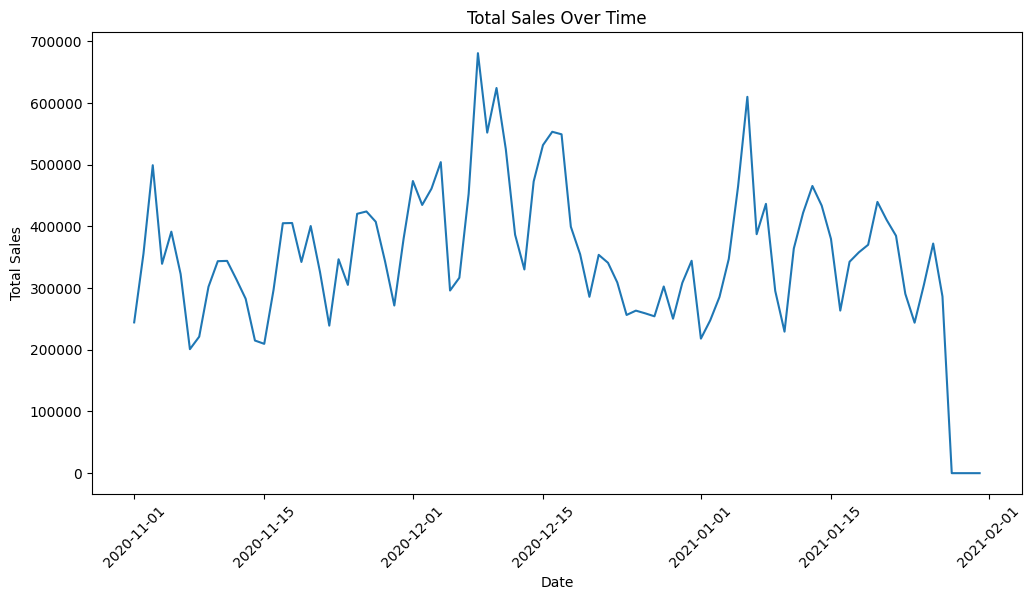

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(sales_by_date.index, sales_by_date["total_sales"])
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Total Sales Over Time")
xticks = plt.xticks(rotation=45)
plt.show()

Daily sales fluctuate considerably throughout the analyzed period, with several noticeable peaks and declines. The highest level of total sales was observed in the first half of December. Sales remained relatively high throughout December, while January showed lower daily sales levels overall.

Although the data reveal clear short-term fluctuations, the analyzed period is relatively short and does not provide enough evidence to reliably identify recurring annual seasonality. A longer observation period, ideally covering at least one full year, would be required to assess seasonal patterns reliably.

In [ ]:
# Sales by month

df["order_date"] = pd.to_datetime(df["order_date"])

sales_by_month = (df.groupby(df["order_date"].dt.to_period("M")).agg(total_sales=("price", "sum"), number_of_orders=("price", "count"), number_of_sessions=("session_id", "nunique")).sort_index())

display(sales_by_month)

,total_sales,number_of_orders,number_of_sessions
order_date,,,
2020-11,9897515.0,10540,105305
2020-12,12423439.3,12903,129358
2021-01,9650776.8,10095,114882


The monthly aggregation shows that December was the strongest month in terms of both sales and customer activity. Total sales increased from 9.90M in November to 12.42M in December, while the number of orders increased from 10,540 to 12,903. The number of sessions also increased from 105,305 to 129,358.

January recorded 9.65M in sales, 10,095 orders and 114,882 sessions. However, the January data cover only part of the month, so the lower values should not be interpreted as a decline in monthly performance compared with November or December.

The increase in sales in December was accompanied by a similar increase in both orders and sessions, suggesting that higher website traffic and a larger number of orders contributed to the stronger sales performance during this period. The relationship between sessions and sales is examined statistically in the following section.


,order_date,continent,total_sales
0,2020-11-01,Americas,132002.5
1,2020-11-01,Asia,63823.0
2,2020-11-01,Europe,46908.0
3,2020-11-02,Americas,193861.0
4,2020-11-02,Asia,79370.0
...,...,...,...
270,2021-01-30,Americas,0.0
272,2021-01-30,Europe,0.0
274,2021-01-31,Asia,0.0
273,2021-01-31,Americas,0.0


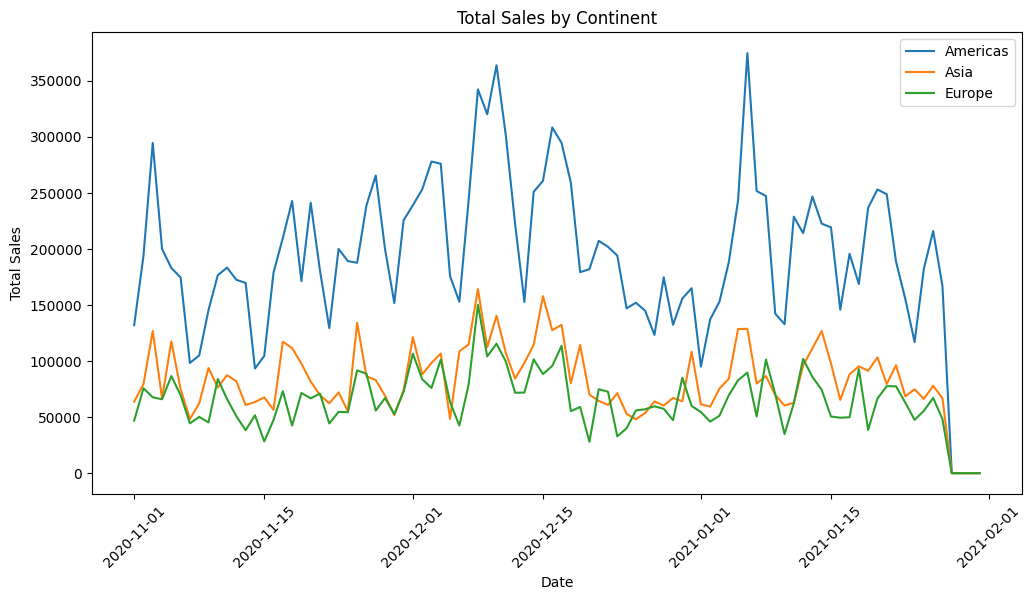

In [ ]:
sales_by_continent_date = (df[df["continent"].isin(["Americas", "Asia", "Europe"])].groupby(["order_date", "continent"]).agg(total_sales=("price", "sum")).reset_index().sort_values("order_date"))

display(sales_by_continent_date)

plt.figure(figsize=(12, 6))

for continent in ["Americas", "Asia", "Europe"]:
    data = sales_by_continent_date[sales_by_continent_date["continent"] == continent]
    plt.plot(data["order_date"] , data["total_sales"], label = continent)

plt.title("Total Sales by Continent")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Sales dynamics differ across the three largest continents. Asia and Europe reached their highest sales levels in the first half of December, while the Americas recorded their peak in the first half of January.

This difference suggests that the timing of peak sales varies between regions. In particular, the later peak in the Americas shows that the overall sales trend can hide important differences in regional purchasing patterns.

However, the analyzed period covers only three months, which is not sufficient to reliably identify recurring seasonal effects. Therefore, these observations should be treated as descriptive patterns rather than evidence of seasonality.


,order_date,traffic_channel,total_sales
0,2020-11-01,Direct,54669.5
1,2020-11-01,Organic Search,95112.0
2,2020-11-01,Paid Search,64688.0
3,2020-11-01,Social Search,25078.0
4,2020-11-01,Undefined,4745.0
...,...,...,...
458,2021-01-31,Social Search,0.0
455,2021-01-31,Direct,0.0
456,2021-01-31,Organic Search,0.0
457,2021-01-31,Paid Search,0.0


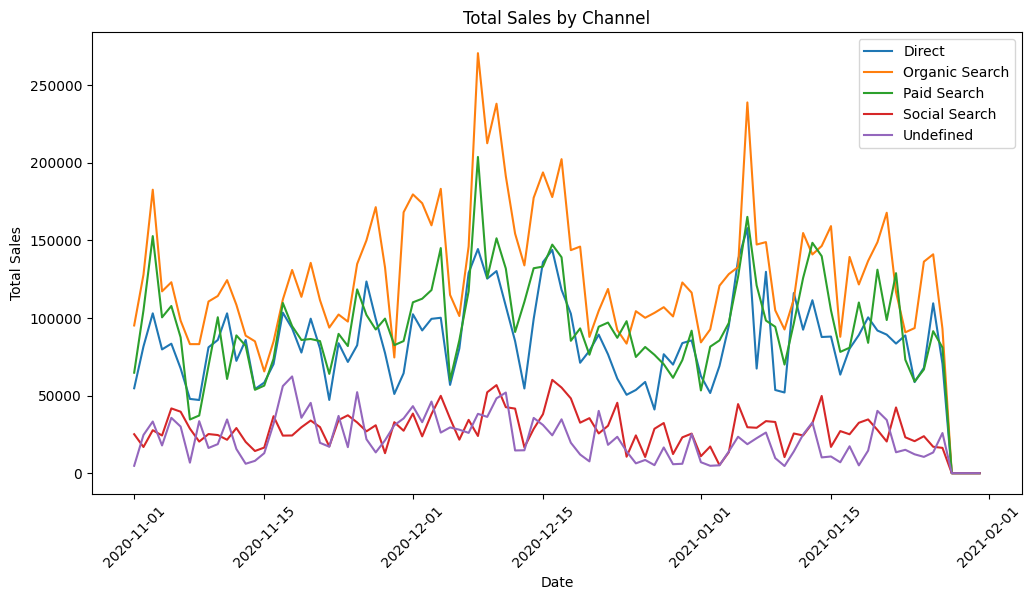

In [ ]:
sales_by_channel_date = (df.groupby(["order_date" , "traffic_channel"]).agg(total_sales=("price", "sum")).reset_index().sort_values("order_date"))

display(sales_by_channel_date)

plt.figure(figsize=(12, 6))

for channel in sales_by_channel_date["traffic_channel"].unique():
    data = sales_by_channel_date[sales_by_channel_date["traffic_channel"] == channel]
    plt.plot(data["order_date"] , data["total_sales"], label = channel)

plt.title("Total Sales by Channel")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Sales dynamics vary noticeably across traffic channels. Undefined traffic reached its highest sales level around the middle of November, while Social traffic peaked around the middle of December. Paid Search and Organic Search reached their highest levels in the first half of December, whereas Direct traffic recorded its highest sales in early January.

The different timing of peak sales across traffic channels suggests that individual sources contribute to revenue differently over time. In particular, the later peak in Direct traffic contrasts with the earlier peaks observed for Organic and Paid Search.

Although these differences are visible in the analyzed period, the dataset covers only three months, so the observed patterns should not be interpreted as evidence of recurring seasonal effects.


,order_date,device,total_sales
0,2020-11-01,desktop,144445.0
1,2020-11-01,mobile,99698.5
2,2020-11-01,tablet,149.0
3,2020-11-02,desktop,206727.3
4,2020-11-02,mobile,137269.5
...,...,...,...
270,2021-01-30,desktop,0.0
272,2021-01-30,tablet,0.0
274,2021-01-31,mobile,0.0
273,2021-01-31,desktop,0.0


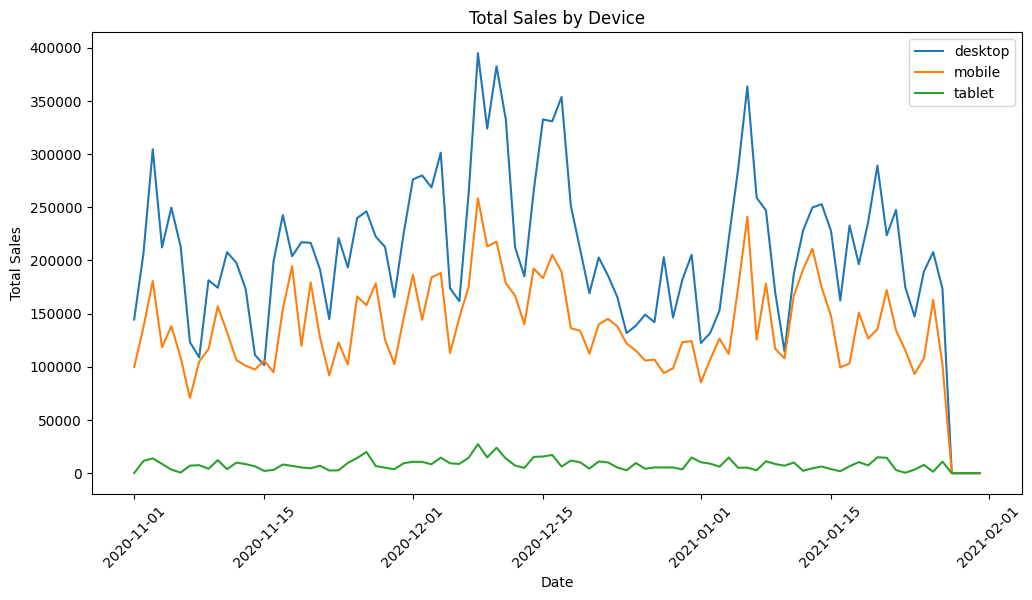

In [ ]:
sales_by_device_date = (df.groupby(["order_date" , "device"]).agg(total_sales=("price", "sum")).reset_index().sort_values("order_date"))

display(sales_by_device_date)

plt.figure(figsize=(12, 6))

for device in sales_by_device_date["device"].unique():
    data = sales_by_device_date[sales_by_device_date["device"] == device]
    plt.plot(data["order_date"] , data["total_sales"], label = device)

plt.title("Total Sales by Device")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Sales dynamics across device types follow a similar pattern. Desktop, mobile and tablet sales all reached their highest levels in the first half of December.

The similar timing of peak sales across devices suggests that the December increase in overall sales was not driven by a single device type, but reflected a broader increase in purchasing activity across different devices. Desktop remained the dominant device type throughout the period, while mobile generated the second-largest share of sales.

### 4.7 Pivot Tables

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


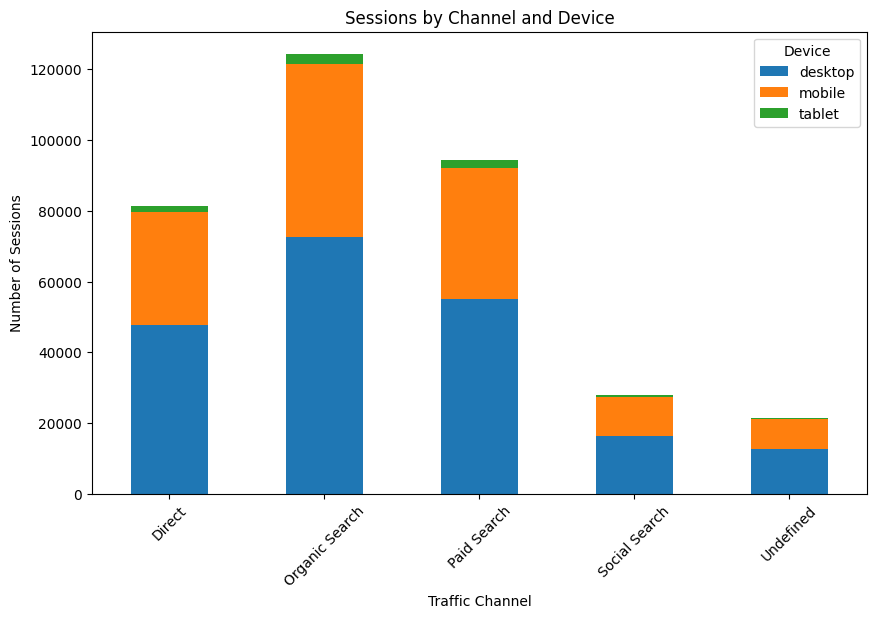

In [ ]:
session_by_channel_device = df.dropna(subset=["traffic_channel", "device"]).pivot_table(index="traffic_channel", columns="device", values="session_id", aggfunc="nunique", fill_value=0)

display(session_by_channel_device)

session_by_channel_device.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sessions by Channel and Device")
plt.xlabel("Traffic Channel")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.legend(title="Device")
plt.show()


The pivot table shows that desktop generated the highest number of sessions across all traffic channels, followed by mobile and tablet. This pattern is consistent across every channel, with desktop accounting for the largest share of sessions regardless of the traffic source.

Organic Search generated the highest number of sessions overall, with 72,622 desktop sessions and 49,014 mobile sessions. Social Search and Undefined traffic generated considerably fewer sessions. Overall, the results indicate that both traffic channel and device type contribute to the distribution of website sessions, while desktop remains the dominant device across all channels.

In [ ]:
# Sales by top product categories and countries

top_categories = sales_by_category.head(10).index
top_countries = sales_by_country.head(5).index

sales_pivot = df[df["product_category"].isin(top_categories) & df["country"].isin(top_countries)].pivot_table(index="product_category", columns="country", values="price", aggfunc="sum", fill_value=0)

display(sales_pivot)


country,Canada,France,India,United Kingdom,United States
product_category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


The pivot table shows that the United States generated the highest sales across all 10 leading product categories, substantially exceeding the other top markets. Sofas & armchairs, Chairs and Beds are the strongest categories in the United States as well as across the other major markets.

The overall ranking of product categories is relatively consistent across countries, with Sofas & armchairs and Chairs generally among the top-performing categories. However, some differences can be observed in the relative sales of individual categories. For example, Beds and Bookcases & shelving units perform particularly strongly in India compared with several other European markets.

Overall, the results suggest that the main product categories are relatively consistent across the largest markets, while the scale of sales is strongly dominated by the United States.

In [ ]:
sales_pivot_continent_device = df.pivot_table(index="continent", columns="device", values="price", aggfunc="sum", fill_value=0)

display(sales_pivot_continent_device)

device,desktop,mobile,tablet
continent,,,
(not set),51643.4,22354.0,70.0
Africa,193643.2,130677.8,6910.0
Americas,10497307.4,6780364.3,387608.3
Asia,4381094.4,3028054.4,192149.5
Europe,3493992.9,2311532.8,129098.5
Oceania,246357.7,111242.5,7630.0


The pivot table shows that desktop devices generated the highest sales across all continents, followed by mobile and tablet devices. This ranking is consistent across all regions, indicating that desktop is the dominant device type regardless of geographic location.

The Americas generated the highest sales across all three device types, followed by Asia and Europe. The difference is particularly pronounced for desktop sales, with the Americas generating approximately $10.5M compared with 4.4M in Asia and 3.5M in Europe.

Overall, the results suggest that the relationship between geographic region and device type is relatively consistent: the main difference between continents is the scale of sales rather than the ranking of device types.


## 5. Statistical Analysis

### 5.1 Correlation Between Sessions and Sales

In [ ]:
correlation = sales_by_date["number_of_sessions"].corr(sales_by_date["total_sales"])

print("Correlation between number of sessions and total sales:", correlation)

Correlation between number of sessions and total sales: 0.7910809164540887


In [ ]:
from scipy.stats import pearsonr

r, p_value = pearsonr(sales_by_date["number_of_sessions"], sales_by_date["total_sales"])

print("Correlation coefficient:", r)
print("P-value:", p_value)

Correlation coefficient: 0.7910809164540891
P-value: 6.483532312080735e-21


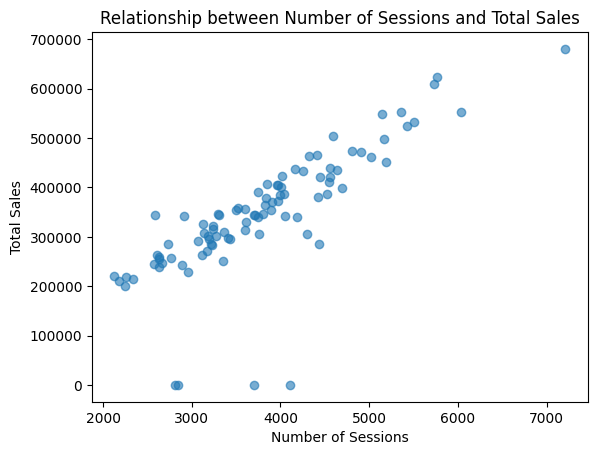

In [ ]:
plt.scatter(sales_by_date["number_of_sessions"], sales_by_date["total_sales"], alpha=0.6)
plt.xlabel("Number of Sessions")
plt.ylabel("Total Sales")
plt.title("Relationship between Number of Sessions and Total Sales")
plt.show()

The Pearson correlation coefficient between the number of sessions and total sales is 0.79, indicating a strong positive linear relationship between the two variables. In general, days with a higher number of sessions tend to be associated with higher total sales.

The p-value is extremely small (p < 0.001), indicating that the observed correlation is statistically significant. Therefore, there is strong evidence of a statistically significant linear relationship between the number of sessions and total sales in the analyzed dataset.

However, correlation does not imply causation. The results indicate that sessions and sales tend to increase and decrease together, but they do not prove that an increase in sessions directly causes an increase in sales.


### 5.2 Correlation Between Continents

In [ ]:
sales_by_continent_date = (df[df["continent"].isin(["Americas", "Asia", "Europe"])].groupby(["order_date", "continent"])["price"].sum().unstack(fill_value=0))

display(sales_by_continent_date)

continent,Americas,Asia,Europe
order_date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0
...,...,...,...
2021-01-27,166735.5,66783.1,48156.1
2021-01-28,0.0,0.0,0.0
2021-01-29,0.0,0.0,0.0


In [ ]:
colleration_matrix = sales_by_continent_date.corr()

display(colleration_matrix)

continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.792025,0.770586
Asia,0.792025,1.000000,0.768427
Europe,0.770586,0.768427,1.000000


In [ ]:
from scipy.stats import pearsonr

continent_pairs = [("Americas", "Asia"), ("Americas", "Europe"), ("Asia", "Europe")]

for continent1, continent2 in continent_pairs:
    r, p_value = pearsonr(sales_by_continent_date[continent1], sales_by_continent_date[continent2])

    print(f"Correlation between {continent1} and {continent2}:")
    print("Correlation coefficient:", r)
    print("P-value:", p_value)
    print()

Correlation between Americas and Asia:
Correlation coefficient: 0.7920245629479414
P-value: 5.409189396197475e-21

Correlation between Americas and Europe:
Correlation coefficient: 0.7705864582886499
P-value: 2.6714492240629956e-19

Correlation between Asia and Europe:
Correlation coefficient: 0.7684273823164164
P-value: 3.8649460090531196e-19



Sales across the three largest continents show strong positive correlations. The strongest relationship was observed between the Americas and Asia (r = 0.79), followed by the Americas and Europe (r = 0.77) and Asia and Europe (r = 0.77).

All three correlations are statistically significant (p < 0.001). Therefore, at the 5% significance level (α = 0.05), the null hypothesis of no linear correlation can be rejected for all three pairs.

These results indicate that sales in the three largest continents tend to increase and decrease together over time. This may suggest that common factors influence sales across regions. However, correlation does not imply causation, and the analysis does not establish that changes in sales in one continent directly cause changes in another.


### 5.3 Correlation Between Traffic Channels

In [ ]:
sales_by_channel_date = (df.groupby(["order_date" , "traffic_channel"])["price"].sum().unstack(fill_value=0))

display(sales_by_channel_date)

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
order_date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4
...,...,...,...,...,...
2021-01-27,70423.1,92921.1,80869.5,16282.0,25845.0
2021-01-28,0.0,0.0,0.0,0.0,0.0
2021-01-29,0.0,0.0,0.0,0.0,0.0


In [ ]:
correlation_matrix_channel = sales_by_channel_date.corr()

display(correlation_matrix_channel)

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
traffic_channel,,,,,
Direct,1.000000,0.837833,0.814072,0.604060,0.517505
Organic Search,0.837833,1.000000,0.870086,0.583117,0.526068
Paid Search,0.814072,0.870086,1.000000,0.596428,0.521961
Social Search,0.604060,0.583117,0.596428,1.000000,0.455126
Undefined,0.517505,0.526068,0.521961,0.455126,1.000000


In [ ]:
channel_pairs = [("Direct", "Organic Search"),("Direct", "Paid Search"), ("Direct", "Social Search"), ("Direct", "Undefined"), ("Organic Search", "Paid Search"), ("Organic Search", "Social Search"), ("Organic Search", "Undefined"), ("Paid Search", "Social Search"), ("Paid Search", "Undefined"), ("Social Search", "Undefined")]

for channel1, channel2 in channel_pairs:
    r, p_value = pearsonr(sales_by_channel_date[channel1], sales_by_channel_date[channel2])

    print(f"Correlation between {channel1} and {channel2}:")
    print("Correlation coefficient:", r)
    print("P-value:", p_value)
    print()

Correlation between Direct and Organic Search:
Correlation coefficient: 0.8378332649310187
P-value: 2.1904196603645366e-25

Correlation between Direct and Paid Search:
Correlation coefficient: 0.8140715620898857
P-value: 5.896434878977516e-23

Correlation between Direct and Social Search:
Correlation coefficient: 0.6040603909721839
P-value: 1.831889246946262e-10

Correlation between Direct and Undefined:
Correlation coefficient: 0.5175046692734796
P-value: 1.2754357002002653e-07

Correlation between Organic Search and Paid Search:
Correlation coefficient: 0.870086120900533
P-value: 2.1420029219324783e-29

Correlation between Organic Search and Social Search:
Correlation coefficient: 0.5831173516286681
P-value: 1.0661924301883206e-09

Correlation between Organic Search and Undefined:
Correlation coefficient: 0.5260682168174377
P-value: 7.228214166055068e-08

Correlation between Paid Search and Social Search:
Correlation coefficient: 0.5964277768036558
P-value: 3.5322844619049755e-10

Co

Sales across all traffic channels show positive correlations, although the strength of the relationships varies. The strongest relationships were observed between Organic Search and Paid Search (r = 0.87), Direct and Organic Search (r = 0.84), and Direct and Paid Search (r = 0.81). These results indicate that the main traffic channels tend to experience similar increases and decreases in sales over time.

The correlations involving Social Search and Undefined traffic are weaker but remain positive. The weakest relationship was observed between Social Search and Undefined traffic (r = 0.46).

All correlations are statistically significant (p < 0.001). Therefore, at the 5% significance level (α = 0.05), the null hypothesis of no linear correlation can be rejected for all pairs of traffic channels.

Overall, sales across different traffic channels tend to move in the same direction over time, although the strength of this relationship varies between channels.

### 5.4 Correlation Between Product Categories

In [ ]:
top_5_categories = sales_by_category.head(5).index.tolist()

print("Top 5 product categories:", top_5_categories)

sales_by_category_date = (df[df["product_category"].isin(top_5_categories)].groupby(["order_date", "product_category"])["price"].sum().unstack(fill_value=0))

display(sales_by_category_date)

Top 5 product categories: ['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards']


product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
order_date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0
...,...,...,...,...,...
2021-01-23,37116.0,29862.7,26068.0,57493.0,76898.0
2021-01-24,23294.0,25396.0,23664.5,54288.0,57837.0
2021-01-25,47303.5,25919.6,33028.0,51424.2,84544.0


In [ ]:
correlation_matrix_category = sales_by_category_date.corr()

display(correlation_matrix_category)

product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
product_category,,,,,
Beds,1.000000,0.592913,0.514609,0.554500,0.535378
Bookcases & shelving units,0.592913,1.000000,0.539428,0.637090,0.666194
Cabinets & cupboards,0.514609,0.539428,1.000000,0.572870,0.657563
Chairs,0.554500,0.637090,0.572870,1.000000,0.578248
Sofas & armchairs,0.535378,0.666194,0.657563,0.578248,1.000000


In [ ]:
category_pairs = [("Beds", "Bookcases & shelving units"), ("Beds", "Cabinets & cupboards"), ("Beds", "Chairs"), ("Beds", "Sofas & armchairs"), ("Bookcases & shelving units", "Cabinets & cupboards"), ("Bookcases & shelving units", "Chairs"), ("Bookcases & shelving units", "Sofas & armchairs"), ("Cabinets & cupboards", "Chairs"), ("Cabinets & cupboards", "Sofas & armchairs"), ("Chairs", "Sofas & armchairs")]


for category1, category2 in category_pairs:
    r, p_value = pearsonr(sales_by_category_date[category1], sales_by_category_date[category2])

    print(f"Correlation between {category1} and {category2}:")
    print("Correlation coefficient:", r)
    print("P-value:", p_value)
    print()


Correlation between Beds and Bookcases & shelving units:
Correlation coefficient: 0.5929126076179512
P-value: 1.1549982399950595e-09

Correlation between Beds and Cabinets & cupboards:
Correlation coefficient: 0.5146092811149645
P-value: 2.9109296191322004e-07

Correlation between Beds and Chairs:
Correlation coefficient: 0.5544997375988838
P-value: 2.079182865492252e-08

Correlation between Beds and Sofas & armchairs:
Correlation coefficient: 0.5353782861422639
P-value: 7.687332925177328e-08

Correlation between Bookcases & shelving units and Cabinets & cupboards:
Correlation coefficient: 0.5394281705433275
P-value: 5.8672250979394714e-08

Correlation between Bookcases & shelving units and Chairs:
Correlation coefficient: 0.6370904868409913
P-value: 2.5045503773672356e-11

Correlation between Bookcases & shelving units and Sofas & armchairs:
Correlation coefficient: 0.6661941326624645
P-value: 1.4069719486806666e-12

Correlation between Cabinets & cupboards and Chairs:
Correlation coe

Sales across the five largest product categories show moderate to strong positive correlations. The strongest relationships were observed between Bookcases & shelving units and Sofas & armchairs (r = 0.67), Cabinets & cupboards and Sofas & armchairs (r = 0.66), and Bookcases & shelving units and Chairs (r = 0.64).

The remaining correlations range from 0.51 to 0.59, indicating that sales in all five categories tend to move in the same direction over time, although the strength of the relationship varies between pairs.

All correlations are statistically significant (p < 0.001). Therefore, at the 5% significance level (α = 0.05), the null hypothesis of no linear correlation can be rejected for all pairs of product categories.

Overall, the results suggest that changes in customer demand tend to affect multiple major product categories simultaneously.

## 6. Statistical Tests for Differences Between Groups

### 6.1 Registered vs Unregistered Users

In [ ]:
registered_sales = (df[df["registered_user_id"].notna()].groupby("order_date")["price"].sum())

unregistered_sales = (df[df["registered_user_id"].isna()].groupby("order_date")["price"].sum())

display(registered_sales)
display(unregistered_sales)

,price
order_date,
2020-11-01,21547.0
2020-11-02,44956.8
2020-11-03,29150.5
2020-11-04,20982.2
2020-11-05,25334.6
...,...
2021-01-23,16117.0
2021-01-24,20914.0
2021-01-25,34163.8


,price
order_date,
2020-11-01,222745.5
2020-11-02,310550.0
2020-11-03,469829.1
2020-11-04,318204.9
2020-11-05,365942.0
...,...
2021-01-27,271727.1
2021-01-28,0.0
2021-01-29,0.0


In [ ]:
print("Registered users:", registered_sales.describe())
print("Unregistered users:", unregistered_sales.describe())

Registered users: count       88.000000
mean     29346.801136
std      10765.451652
min      11779.000000
25%      20717.375000
50%      28048.000000
75%      35774.700000
max      68151.100000
Name: price, dtype: float64
Unregistered users: count        92.000000
mean     319447.963043
std      113764.392969
min           0.000000
25%      263005.700000
50%      315170.750000
75%      375010.750000
max      612358.400000
Name: price, dtype: float64


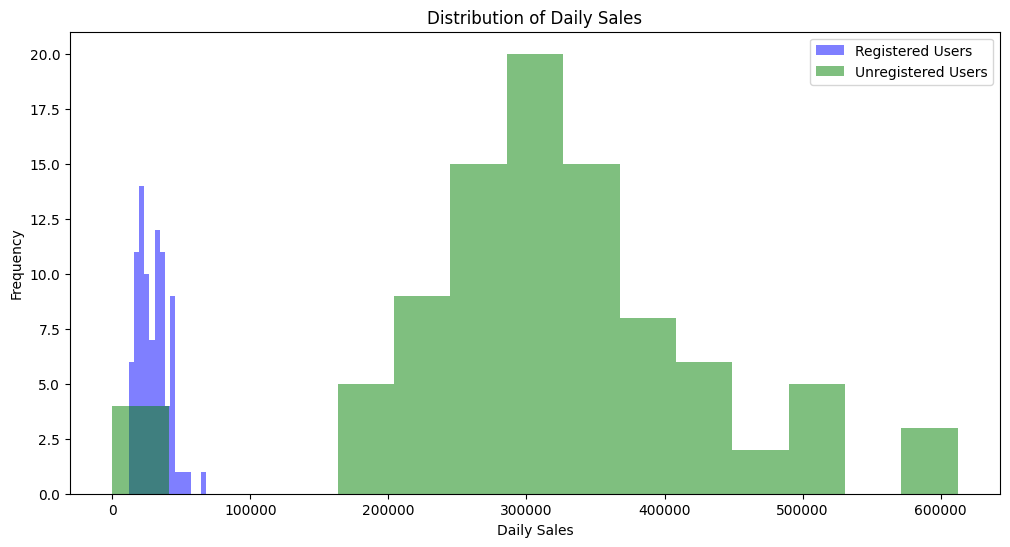

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(registered_sales, bins=15, alpha=0.5, label="Registered Users", color="blue")
plt.hist(unregistered_sales, bins=15, alpha=0.5, label="Unregistered Users", color="green")
plt.xlabel("Daily Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Sales")
plt.legend()
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(registered_sales, unregistered_sales)

print("Mann-Whitney U test statistic:", statistic)
print("P-value:", p_value)

Mann-Whitney U test statistic: 352.0
P-value: 3.8805185465235906e-26


The histogram shows a clear difference in the distribution of daily sales between registered and unregistered users. Daily sales associated with unregistered users are generally much higher than those associated with registered users, while the registered-user group is concentrated at substantially lower values.

Because the distributions are not necessarily normally distributed, the Mann–Whitney U test was used to compare the two groups. The test returned a U statistic of 352 and a p-value below 0.001, indicating a statistically significant difference between the distributions. Therefore, at the 5% significance level (α = 0.05), the null hypothesis that the two groups come from the same distribution can be rejected.

The results indicate that daily sales associated with unregistered users were significantly higher than those associated with registered users during the analyzed period.

### 6.2 Sales by Device

In [ ]:
sales_by_device_date = (df.groupby(["order_date" , "device"])["price"].sum().unstack(fill_value=0))

display(sales_by_device_date)

device,desktop,mobile,tablet
order_date,,,
2020-11-01,144445.0,99698.5,149.0
2020-11-02,206727.3,137269.5,11510.0
2020-11-03,304473.8,180602.8,13903.0
2020-11-04,212227.7,118324.4,8635.0
2020-11-05,249682.0,138256.0,3338.6
...,...,...,...
2021-01-27,173453.5,102042.2,10845.0
2021-01-28,0.0,0.0,0.0
2021-01-29,0.0,0.0,0.0


In [ ]:
from scipy.stats import kruskal

statistic, p_value = kruskal(sales_by_device_date["desktop"], sales_by_device_date["mobile"], sales_by_device_date["tablet"])

print("Kruskal-Wallis test statistic:", statistic)
print("P-value:", p_value)

Kruskal-Wallis test statistic: 178.03003203425416
P-value: 2.194167294023942e-39


In [ ]:
devices_pairs = [("desktop", "mobile"), ("desktop", "tablet"), ("mobile", "tablet")]

for device1, device2 in devices_pairs:
    statistic, p_value = mannwhitneyu(sales_by_device_date[device1], sales_by_device_date[device2])

    print(f"Mann-Whitney U test between {device1} and {device2}:")
    print("U statistic:", statistic)
    print("P-value:", p_value)
    print()

Mann-Whitney U test between desktop and mobile:
U statistic: 6914.0
P-value: 1.1401231481979903e-13

Mann-Whitney U test between desktop and tablet:
U statistic: 8104.0
P-value: 8.37907309189504e-27

Mann-Whitney U test between mobile and tablet:
U statistic: 8104.0
P-value: 8.37907309189504e-27



The Kruskal–Wallis test was used to compare daily sales across desktop, mobile and tablet devices. The test returned a statistic of 178.03 and a p-value below 0.001, indicating a statistically significant difference between the groups. Therefore, at the 5% significance level (α = 0.05), the null hypothesis that the groups have the same distribution can be rejected.

To identify which device types differ from each other, pairwise Mann–Whitney U tests were performed. All three pairwise comparisons were statistically significant (p < 0.001), indicating significant differences between desktop and mobile, desktop and tablet, and mobile and tablet sales.

Overall, the results show that daily sales distributions differ significantly across all three device types, with the largest differences observed between desktop and tablet and between mobile and tablet.

### 6.3 Sales by Traffic Channel

In [ ]:
statistic, p_value = kruskal(sales_by_channel_date["Direct"], sales_by_channel_date["Organic Search"], sales_by_channel_date["Paid Search"], sales_by_channel_date["Social Search"], sales_by_channel_date["Undefined"])

print("Kruskal-Wallis test statistic:", statistic)
print("P-value:", p_value)


Kruskal-Wallis test statistic: 296.2573085894095
P-value: 6.951906572594659e-63


In [ ]:
channel_pairs = [("Direct", "Organic Search"),("Direct", "Paid Search"), ("Direct", "Social Search"), ("Direct", "Undefined"), ("Organic Search", "Paid Search"), ("Organic Search", "Social Search"), ("Organic Search", "Undefined"), ("Paid Search", "Social Search"), ("Paid Search", "Undefined"), ("Social Search", "Undefined")]

for channel1, channel2 in channel_pairs:
    statistic, p_value = mannwhitneyu(sales_by_channel_date[channel1], sales_by_channel_date[channel2])

    print(f"Mann-Whitney U test between {channel1} and {channel2}:")
    print("U statistic:", statistic)
    print("P-value:", p_value)
    print()


Mann-Whitney U test between Direct and Organic Search:
U statistic: 1547.0
P-value: 1.070757088855781e-13

Mann-Whitney U test between Direct and Paid Search:
U statistic: 3299.5
P-value: 0.009874777863230136

Mann-Whitney U test between Direct and Social Search:
U statistic: 8035.0
P-value: 6.488399364733536e-26

Mann-Whitney U test between Direct and Undefined:
U statistic: 8051.0
P-value: 4.049591196027296e-26

Mann-Whitney U test between Organic Search and Paid Search:
U statistic: 6249.0
P-value: 2.370155821629555e-08

Mann-Whitney U test between Organic Search and Social Search:
U statistic: 8104.0
P-value: 8.379540669190225e-27

Mann-Whitney U test between Organic Search and Undefined:
U statistic: 8104.0
P-value: 8.379540669190225e-27

Mann-Whitney U test between Paid Search and Social Search:
U statistic: 8054.0
P-value: 3.7062177399073884e-26

Mann-Whitney U test between Paid Search and Undefined:
U statistic: 8065.0
P-value: 2.6765942719693894e-26

Mann-Whitney U test betwee

The Kruskal–Wallis test was used to compare daily sales across the five traffic channels. The test returned a statistic of 296.26 and a p-value below 0.001, indicating a statistically significant difference between the groups. Therefore, at the 5% significance level (α = 0.05), the null hypothesis that the traffic channels have the same distribution can be rejected.

Pairwise Mann–Whitney U tests were then performed to identify which traffic channels differ from each other. Most pairwise comparisons were statistically significant (p < 0.05). The weakest evidence of a difference was observed for Direct vs Paid Search (p = 0.0099) and Social Search vs Undefined (p = 0.0021), although both results are still statistically significant at the 5% level.

Overall, the results indicate that daily sales distributions differ significantly across traffic channels, with the strongest differences observed between the main channels and the lower-volume Social Search and Undefined groups.

### 6.4 Sales by Continent

In [ ]:
statistic, p_value = kruskal(sales_by_continent_date["Americas"], sales_by_continent_date["Asia"], sales_by_continent_date["Europe"])

print("Kruskal-Wallis test statistic:", statistic)
print("P-value:", p_value)

continent_pairs = [("Americas", "Asia"), ("Americas", "Europe"), ("Asia", "Europe")]

for continent1, continent2 in continent_pairs:
    statistic, p_value = mannwhitneyu(sales_by_continent_date[continent1], sales_by_continent_date[continent2])

    print(f"Mann-Whitney U test between {continent1} and {continent2}:")
    print("U statistic:", statistic)
    print("P-value:", p_value)
    print()

Kruskal-Wallis test statistic: 153.24803523098103
P-value: 5.2797330952955e-34
Mann-Whitney U test between Americas and Asia:
U statistic: 7901.0
P-value: 3.1157436729581436e-24

Mann-Whitney U test between Americas and Europe:
U statistic: 8052.0
P-value: 3.931766634286664e-26

Mann-Whitney U test between Asia and Europe:
U statistic: 5843.0
P-value: 8.250967212521779e-06



The Kruskal–Wallis test was used to compare daily sales across the three largest continents: the Americas, Asia and Europe. The test returned a statistic of 153.25 and a p-value below 0.001, indicating a statistically significant difference between the groups. Therefore, at the 5% significance level (α = 0.05), the null hypothesis that the three continents have the same distribution can be rejected.

Pairwise Mann–Whitney U tests were then performed to identify differences between individual continents. All three comparisons were statistically significant (p < 0.05), indicating significant differences in daily sales between the Americas and Asia, the Americas and Europe, and Asia and Europe.

Overall, the results indicate that daily sales distributions differ significantly across all three largest continents.

### 6.5 Sessions by Traffic Channel

In [ ]:
session_by_channel_date = (df.groupby(["order_date" , "traffic_channel"])["session_id"].nunique().unstack(fill_value=0))

display(session_by_channel_date)

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
order_date,,,,,
2020-11-01,608,920,706,214,128
2020-11-02,810,1242,970,315,262
2020-11-03,1216,1871,1367,392,327
2020-11-04,935,1425,1145,368,311
2020-11-05,845,1293,917,346,342
...,...,...,...,...,...
2021-01-27,984,1561,1192,359,339
2021-01-28,997,1379,1107,364,265
2021-01-29,878,1319,988,288,227


In [ ]:
statistic, p_value = kruskal(session_by_channel_date["Direct"], session_by_channel_date["Organic Search"], session_by_channel_date["Paid Search"], session_by_channel_date["Social Search"], session_by_channel_date["Undefined"])

print("Kruskal-Wallis test statistic:", statistic)
print("P-value:", p_value)

for channel1, channel2 in channel_pairs:
    statistic, p_value = mannwhitneyu(session_by_channel_date[channel1], session_by_channel_date[channel2])

    print(f"Mann-Whitney U test between {channel1} and {channel2}:")
    print("U statistic:", statistic)
    print("P-value:", p_value)
    print()

Kruskal-Wallis test statistic: 368.98057369864847
P-value: 1.397036102599359e-78
Mann-Whitney U test between Direct and Organic Search:
U statistic: 924.0
P-value: 5.3708169240433403e-20

Mann-Whitney U test between Direct and Paid Search:
U statistic: 2839.5
P-value: 0.0001164175646466701

Mann-Whitney U test between Direct and Social Search:
U statistic: 8456.0
P-value: 1.3987306412128271e-31

Mann-Whitney U test between Direct and Undefined:
U statistic: 8464.0
P-value: 1.0757816219104898e-31

Mann-Whitney U test between Organic Search and Paid Search:
U statistic: 6688.5
P-value: 1.053138070470278e-11

Mann-Whitney U test between Organic Search and Social Search:
U statistic: 8464.0
P-value: 1.0776450239196524e-31

Mann-Whitney U test between Organic Search and Undefined:
U statistic: 8464.0
P-value: 1.076068095331289e-31

Mann-Whitney U test between Paid Search and Social Search:
U statistic: 8464.0
P-value: 1.0773581427994148e-31

Mann-Whitney U test between Paid Search and Undef

The Kruskal–Wallis test was used to compare daily sales across the five traffic channels. The test returned a statistic of 368.98 and a p-value below 0.001, indicating a statistically significant difference between the groups. Therefore, at the 5% significance level (α = 0.05), the null hypothesis that the five groups have the same distribution can be rejected.

Pairwise Mann–Whitney U tests were then performed to identify differences between individual traffic channels. All pairwise comparisons were statistically significant (p < 0.05), indicating that daily sales distributions differ significantly between every pair of traffic channels.

Overall, the results indicate that traffic channel is significantly associated with differences in the distribution of daily sales.

### 6.6 Organic Search: Europe vs Americas

In [ ]:
organic_session = df[(df["traffic_channel"] == "Organic Search") & (df["continent"].isin(["Europe", "Americas"]))].groupby("continent")["session_id"].nunique()

total_session = (df[df["continent"].isin(["Europe", "Americas"])].groupby("continent")["session_id"].nunique())

print("Organic Sessions by Continent:")
print(organic_session)

print("\nTotal Sessions by Continent:")
print(total_session)

Organic Sessions by Continent:
continent
Americas    68671
Europe      23195
Name: session_id, dtype: int64

Total Sessions by Continent:
continent
Americas    193179
Europe       65135
Name: session_id, dtype: int64


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

successes = [organic_session["Americas"], organic_session["Europe"]]
totals = [total_session["Americas"], total_session["Europe"]]

statistic, p_value = proportions_ztest(successes, totals)

print("Z-test statistic:", statistic)
print("P-value:", p_value)

Z-test statistic: -0.28951412926103953
P-value: 0.7721879690501752


The proportion of sessions coming from Organic Search was very similar in the Americas and Europe. Organic Search accounted for approximately 35.5% of sessions in the Americas and 35.6% in Europe.

A two-proportion z-test was used to compare the share of Organic Search sessions between the two continents. The test returned a z-statistic of -0.29 and a p-value of 0.772. Since p > 0.05, the result is not statistically significant and the null hypothesis cannot be rejected.

Therefore, there is no statistically significant evidence of a difference in the proportion of Organic Search sessions between the Americas and Europe in the analyzed dataset.

## 7. Key Findings

The analysis revealed several important patterns in the company's sales performance.

- The Americas were the largest market, generating approximately 55% of total sales, with the United States being the dominant country.
- Sofas & armchairs, Chairs and Beds were the three strongest product categories and together accounted for a substantial share of total sales.
- Desktop was the dominant device type, generating approximately 59% of total sales, followed by mobile with approximately 39%.
- Organic Search was the largest traffic source, accounting for approximately 34% of total sales.
- December was the strongest month in the analyzed period in terms of total sales, orders and sessions. However, January covered only part of the month, limiting direct monthly comparisons.
- Sales showed a strong positive correlation with the number of sessions (r = 0.79, p < 0.001), indicating that days with more sessions generally had higher sales.
- Sales across the largest continents, traffic channels and product categories were positively correlated, suggesting that these groups often followed similar sales patterns over time.
- Statistical tests showed significant differences in daily sales across device types, traffic channels and the three largest continents.
- The proportion of Organic Search sessions did not differ significantly between the Americas and Europe (p = 0.772).
- Registered and unregistered users showed significantly different distributions of daily sales, with higher sales associated with unregistered users in the analyzed sample.

From a business perspective, the results suggest that the United States and the Americas are particularly important markets, while Sofas & armchairs and Chairs represent key product categories. Desktop users remain the largest source of sales, although mobile also contributes substantially to overall revenue.

The strong relationship between website sessions and sales suggests that increasing relevant website traffic may be important for overall sales performance. At the same time, the differences observed between traffic channels, devices and geographic regions indicate that customer behavior is not uniform across all segments.


This analysis provided an overview of the company's sales performance across geographic regions, product categories, devices, traffic channels and user groups.

The results showed clear differences in sales between customer segments, while statistical analysis identified several significant relationships and differences between groups. The analysis also highlighted the importance of the Americas, particularly the United States, and the strong contribution of the leading furniture categories.

The results should be interpreted in the context of the available data. In particular, the relatively short observation period and incomplete January data limit the ability to draw conclusions about long-term trends and seasonality. Nevertheless, the analysis provides useful insights into the main drivers and patterns of sales during the analyzed period.

## 8. Tableau Dashboard


An interactive Tableau Public dashboard was created to provide a visual summary of the key findings from the sales analysis. The dashboard consists of two interconnected views.

The first dashboard, **Sales Overview**, presents the main sales KPIs and provides an overview of sales performance over time, across continents, countries, product categories and device types.

The second dashboard, **Traffic & Users**, focuses on traffic channels and user behavior. It presents sales by traffic channel, changes in sales by channel over time, device trends, registered vs unregistered users, and session activity by traffic channel.

The two dashboards are connected, allowing users to move from the overall sales overview to a more detailed analysis of traffic and user-related patterns.

**Tableau Public:** [View the interactive dashboard](https://public.tableau.com/views/Book1_17685805768380/SALESOVERVIEW?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)


## 9. Conclusion

This analysis provided an overview of the company's sales performance across geographic regions, product categories, devices, traffic channels and user groups.

The results showed clear differences in sales between customer segments, while statistical analysis identified several significant relationships and differences between groups. The analysis also highlighted the importance of the Americas, particularly the United States, and the strong contribution of the leading furniture categories.

The results should be interpreted in the context of the available data. In particular, the relatively short observation period and incomplete January data limit the ability to draw conclusions about long-term trends and seasonality. Nevertheless, the analysis provides useful insights into the main drivers and patterns of sales during the analyzed period.